In [1]:
!pip install ultralytics transformers opencv-python pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# YOLO
yolo_model = YOLO("/content/drive/MyDrive/SIB/receipt-yolo/receipt_model/weights/best.pt")

# TrOCR
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
ocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed").to(device)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
def preprocess_image(crop):
    # 1. Grayscale
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    # 2. Resize (biar teks kecil jadi lebih jelas)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    # 3. Denoising
    denoise = cv2.fastNlMeansDenoising(gray, None, 30, 7, 21)

    # 4. Adaptive Threshold (lebih bagus dari threshold biasa)
    thresh = cv2.adaptiveThreshold(
        denoise,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    # 5. Morphology (biar teks lebih tebal & jelas)
    kernel = np.ones((2,2), np.uint8)
    morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    return morph

In [5]:
def extract_text(crop_img):
    pil_img = Image.fromarray(crop_img)

    pixel_values = processor(
        images=pil_img,
        return_tensors="pt"
    ).pixel_values.to(device)

    generated_ids = ocr_model.generate(
        pixel_values,
        max_length=64,
        num_beams=5,              # beam search biar lebih akurat
        early_stopping=True,
        no_repeat_ngram_size=2    # hindari kata aneh berulang
    )

    text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return text.strip()


0: 640x640 1 Address, 1 Date, 1 Item, 1 OrderId, 1 Subtotal, 2 Taxs, 1 Title, 1 TotalPrice, 1030.1ms
Speed: 15.5ms preprocess, 1030.1ms inference, 44.4ms postprocess per image at shape (1, 3, 640, 640)


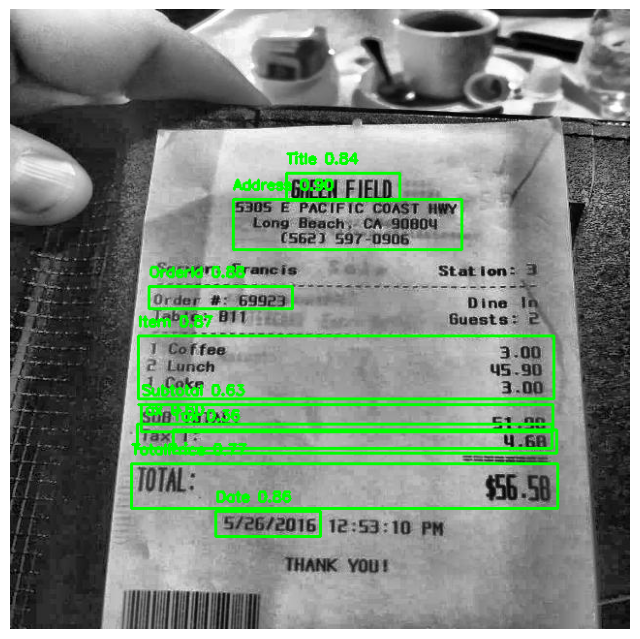

In [7]:
image_path = "/content/1000-receipt_jpg.rf.4be30818ff1b2563f126aef479ce5b3e.jpg"

# reset
output_text = []

image = cv2.imread(image_path)

if image is None:
    print("❌ Gambar tidak ditemukan!")
else:
    results = yolo_model(image)[0]

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        label = yolo_model.names[cls]
        conf = float(box.conf[0])

        if conf < 0.2:
            continue

        crop = image[y1:y2, x1:x2]
        crop_processed = preprocess_image(crop)

        text = extract_text(crop_processed)

        output_text.append({
            "label": label,
            "confidence": conf,
            "text": text
        })

        cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(image, f"{label} {conf:.2f}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

# gambar bbox
plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [8]:
# tampilkan hasil OCR
print("\n=== HASIL EKSTRAKSI ===\n")
for item in output_text:
    print(f"[{item['label']}] ({item['confidence']})")
    print(item['text'] if item['text'] else "(kosong)")
    print("-" * 40)


=== HASIL EKSTRAKSI ===

[Address] (0.9047189950942993)
SALONG BOODY CA 980004
----------------------------------------
[OrderId] (0.8819212913513184)
ORDER #: 69923
----------------------------------------
[Item] (0.8713086843490601)
: CASH RECEIPT + 5.98
----------------------------------------
[Date] (0.8629993200302124)
5/26/2016
----------------------------------------
[Title] (0.8423349261283875)
6%2% FIELD
----------------------------------------
[TotalPrice] (0.7659497261047363)
TOTAL: 065.58
----------------------------------------
[Subtotal] (0.6318853497505188)
SUB TOTAL:
----------------------------------------
[Tax] (0.5950559973716736)
TAX INCLUSIONS - 4.68
----------------------------------------
[Tax] (0.36191681027412415)
R ICE 4.68
----------------------------------------
